# Prepare Human Comments Reference

This notebook builds the cleaned expert-comment reference from `uicrit_notna_parsed.parquet`. It saves two
task-level tables (one row per screen task with a `comments` list):

- `human_comments_exact_dedup.parquet`: comments with an observed issue, without exact duplicates (Section 1)
- `human_comments_semantic_dedup.parquet`: the same, without semantic duplicates (Section 2)

All deduplication happens **within the same task**; comments from different tasks are never merged.

# 0. Setup

In [1]:
import re
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils" / "paths.py").exists())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from utils.comments.pairs import explode_comments
from utils.paths import HUMAN_REFERENCE_DIR as DATA_DIR, PARSED_DIR, PREPROCESSED_DIR, SCREENS_DIR
from utils.screen_display import show_screen

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 50)

INPUT_PATH = PARSED_DIR / "uicrit_notna_parsed.parquet"
EXACT_DEDUP_PATH = DATA_DIR / "human_comments_exact_dedup.parquet"
SEMANTIC_DEDUP_PATH = DATA_DIR / "human_comments_semantic_dedup.parquet"
OUTPUT_DIR = DATA_DIR / "deduplicating_semantic_human_critiques"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TASK_METADATA_COLS = ["screen_id", "app", "app_category", "screen_task_id", "task"]
FINAL_TASK_COLS = TASK_METADATA_COLS + ["comments"]
COMMENT_PAYLOAD_COLS = [
    "comment_id",
    "comment_label",
    "comment_source",
    "expected_standard",
    "observed_issue",
    "suggested_fix",
    "missing_parts",
    "bounding_box",
    "raw_text",
]

TASK_TEXT_DEDUP_KEY = ["screen_task_id", "observed_issue_norm"]
SAME_TARGET_IOU_THRESHOLD = 0.50
REVIEW_TARGET_IOU_THRESHOLD = 0.10

QUOTES = str.maketrans({"’": "'", "‘": "'", "“": '"', "”": '"'})


def normalize_text(value):
    """Lowercased text with plain quotes, single spaces and no leading/trailing punctuation (None if empty)."""
    if not isinstance(value, str):
        return None
    text = re.sub(r"\s+", " ", value.strip().lower().translate(QUOTES))
    return re.sub(r"^[^\w]+|[^\w]+$", "", text) or None


def nest_comments(comments_df):
    """One row per task with its comments as a list of dicts (the saved reference format)."""
    return (
        comments_df.sort_values(["screen_id", "screen_task_id", "comment_label"], kind="stable")
        .groupby(TASK_METADATA_COLS, sort=True, dropna=False)[COMMENT_PAYLOAD_COLS]
        .apply(lambda comments: comments.to_dict(orient="records"))
        .reset_index(name="comments")
    )

# 1. Removing Missing and Exact Duplicate Comments

## 1.1 Load Parsed Comments

The input table is currently at screen-task level, with `parsed_comments` stored as a list of dictionaries.

In [2]:
uicrit_df = pd.read_parquet(INPUT_PATH)

print("Rows (screen-task level):", len(uicrit_df))
print("Unique screens:", uicrit_df["screen_id"].nunique())
print("Unique screen-task ids:", uicrit_df["screen_task_id"].nunique())
print("Rows with parsed comments:", uicrit_df["parsed_comments"].notna().sum())

uicrit_df[["screen_task_id", "task", "parsed_comments"]].head(2)


Rows (screen-task level): 2955
Unique screens: 1000
Unique screen-task ids: 2955
Rows with parsed comments: 2955


,screen_task_id,task,parsed_comments
0,15_T01,Plan and Start Full Body Workouts,"[{'bounding_box': {'x_max': 0.40545597, 'x_min': 0.1559446, 'y_max': 0.09649163, 'y_min': 0.05137866}, 'comment_label': 'Comment 1', 'comment_source': 'Huma..."
1,15_T02,Tap on the Plus icon or explore the Workout Plans.,"[{'bounding_box': {'x_max': 0.10555714, 'x_min': 0.02777819, 'y_max': 0.10937545, 'y_min': 0.04375018}, 'comment_label': 'Comment 1', 'comment_source': 'Hum..."


## 1.2 Flatten To Comment-Level Long Format

Each parsed comment becomes one row while preserving task provenance and its linked screen metadata.

In [3]:
raw_comments_df = explode_comments(uicrit_df[TASK_METADATA_COLS + ["parsed_comments"]], "parsed_comments")

comment_number = raw_comments_df.groupby("screen_task_id", sort=False).cumcount() + 1
raw_comments_df.insert(0, "comment_id", raw_comments_df["screen_task_id"] + "_" + comment_number.astype(str).str.zfill(3))

print("Comment-level rows:", len(raw_comments_df))
display(raw_comments_df.drop(columns=["comment_label"], errors="ignore").head(3))

Comment-level rows: 11358


,comment_id,screen_id,app,app_category,screen_task_id,task,bounding_box,comment_source,expected_standard,missing_parts,observed_issue,raw_text,suggested_fix
0,15_T01_001,15,Seven - 7 Minute Workout,Health & Fitness,15_T01,Plan and Start Full Body Workouts,"{'x_max': 0.40545597, 'x_min': 0.1559446, 'y_max': 0.09649163, 'y_min': 0.05137866}",Human,the text’s visual treatment and formatting should make it easy to understand.,[],the text (Workouts) is small even when it is heading.,"Comment 1 The expected standard is that the text’s visual treatment and formatting should make it easy to understand. In the current design, the text (Worko...",increase font size and weight to make it look like a heading
1,15_T01_002,15,Seven - 7 Minute Workout,Health & Fitness,15_T01,Plan and Start Full Body Workouts,"{'x_max': 0.1559446, 'x_min': 0.02896114, 'y_max': 0.18045189, 'y_min': 0.15037657}",Human,the text and background colors used in the design should be complementary and easy to read.,[],text (Plans) is in light red color on white background which is not making a good contrast.,"Comment 2 The expected standard is that the text and background colors used in the design should be complementary and easy to read. In the current design, t...",change colors to be more complementary to each other (change texts to dark colors) to make it a good contrast and easier to read.
2,15_T01_003,15,Seven - 7 Minute Workout,Health & Fitness,15_T01,Plan and Start Full Body Workouts,"{'x_max': 0.1002501, 'x_min': 0.03787226, 'y_max': 0.09147908, 'y_min': 0.05513808}",Human,the design should make the most important information visually dominant.,[],the back button size is small.,"Comment 3 The expected standard is that the design should make the most important information visually dominant. In the current design, the back button size...",increase the back button size to make it visually prominent for the users.


## 1.3 Normalize Text Fields

Normalized copies of the text fields drive exact deduplication; the original text is kept.

In [4]:
for field in ["expected_standard", "observed_issue", "suggested_fix"]:
    raw_comments_df[f"{field}_norm"] = raw_comments_df[field].map(normalize_text)

raw_comments_df[["comment_id", "screen_task_id", "comment_source", "observed_issue", "observed_issue_norm"]].head(5)

,comment_id,screen_task_id,comment_source,observed_issue,observed_issue_norm
0,15_T01_001,15_T01,Human,the text (Workouts) is small even when it is heading.,the text (workouts) is small even when it is heading
1,15_T01_002,15_T01,Human,text (Plans) is in light red color on white background which is not making a good contrast.,text (plans) is in light red color on white background which is not making a good contrast
2,15_T01_003,15_T01,Human,the back button size is small.,the back button size is small
3,15_T01_004,15_T01,Human,the texts are disappearing at the bottom edge of the layout leaving no marginal space which is making it difficult for users to know the complete information,the texts are disappearing at the bottom edge of the layout leaving no marginal space which is making it difficult for users to know the complete information
4,15_T01_005,15_T01,Human,Icon is not clearly visible,icon is not clearly visible


## 1.4 Drop Comments Without An Observed Issue

In [5]:
missing_observed_issue = raw_comments_df["observed_issue_norm"].isna()
filtered_human_comments_df = raw_comments_df[~missing_observed_issue].copy()

print("Removed comments without an observed issue:", int(missing_observed_issue.sum()))
print("Remaining comments:", len(filtered_human_comments_df))

Removed comments without an observed issue: 7
Remaining comments: 11351


## 1.5 Deduplicate Within The Same Task

First, drop exact duplicate triplets within the same `screen_task_id` when their normalized
`expected_standard`, `observed_issue` and `suggested_fix` match **and** their bounding boxes point to
the same target region.

Rows that still repeat on normalized `observed_issue` are grouped into bbox-overlap components. Only
same-issue rows with overlapping, ambiguous or missing localization go to manual review; same-issue rows
with very low IoU critique different UI elements and are kept.

In [6]:
from itertools import combinations

BBOX_KEYS = ["x_min", "y_min", "x_max", "y_max"]
TASK_TRIPLET_KEY = ["screen_task_id", "expected_standard_norm", "observed_issue_norm", "suggested_fix_norm"]
TASK_DUPLICATE_GROUP_KEY = ["screen_task_id", "observed_issue_norm", "bbox_component"]
REVIEW_EDGE_STATUSES = {"same_target", "same_target_missing_bbox", "manual_missing_bbox", "manual_ambiguous_target"}


def bbox_to_tuple(bbox):
    """(x_min, y_min, x_max, y_max) of a bounding-box dict, or None when it is missing or has no area."""
    if not isinstance(bbox, dict) or any(bbox.get(key) is None for key in BBOX_KEYS):
        return None
    x_min, x_max = sorted((float(bbox["x_min"]), float(bbox["x_max"])))
    y_min, y_max = sorted((float(bbox["y_min"]), float(bbox["y_max"])))
    return (x_min, y_min, x_max, y_max) if x_max > x_min and y_max > y_min else None


def bbox_iou(left, right):
    left, right = bbox_to_tuple(left), bbox_to_tuple(right)
    if left is None or right is None:
        return None
    width = max(0.0, min(left[2], right[2]) - max(left[0], right[0]))
    height = max(0.0, min(left[3], right[3]) - max(left[1], right[1]))
    intersection = width * height
    union = (left[2] - left[0]) * (left[3] - left[1]) + (right[2] - right[0]) * (right[3] - right[1]) - intersection
    return intersection / union if union > 0 else None


def bbox_pair_status(left, right):
    iou = bbox_iou(left, right)
    if iou is None:
        both_missing = bbox_to_tuple(left) is None and bbox_to_tuple(right) is None
        return ("same_target_missing_bbox" if both_missing else "manual_missing_bbox"), iou
    if iou >= SAME_TARGET_IOU_THRESHOLD:
        return "same_target", iou
    if iou >= REVIEW_TARGET_IOU_THRESHOLD:
        return "manual_ambiguous_target", iou
    return "different_target", iou


def build_overlap_components(group_df, edge_statuses):
    """Label rows linked by an edge status into bbox components; also return every row pair's IoU and status."""
    rows = group_df.reset_index(drop=True)
    parent = list(range(len(rows)))

    def find(i):
        while parent[i] != i:
            i = parent[i]
        return i

    pair_records = []
    for i, j in combinations(range(len(rows)), 2):
        status, iou = bbox_pair_status(rows.at[i, "bounding_box"], rows.at[j, "bounding_box"])
        pair_records.append({
            "left_comment_id": rows.at[i, "comment_id"],
            "right_comment_id": rows.at[j, "comment_id"],
            "bbox_iou": iou,
            "bbox_pair_status": status,
        })
        if status in edge_statuses:
            parent[find(j)] = find(i)

    roots = [find(i) for i in range(len(rows))]
    component_numbers = {root: number for number, root in enumerate(dict.fromkeys(roots))}
    return rows.assign(bbox_component=[component_numbers[root] for root in roots]), pd.DataFrame(pair_records)


def find_bbox_duplicate_components(df, group_key, edge_statuses):
    """Rows that share `group_key` and are linked by their boxes (components of 2+), plus every pair compared."""
    component_frames, pair_frames = [], []
    for group_values, group_df in df[df.duplicated(group_key, keep=False)].groupby(group_key, dropna=False, sort=False):
        component_df, pair_df = build_overlap_components(group_df, edge_statuses)
        pair_frames.append(pair_df.assign(**dict(zip(group_key, group_values))))
        component_frames += [rows for _, rows in component_df.groupby("bbox_component", sort=False) if len(rows) > 1]
    components_df = pd.concat(component_frames, ignore_index=True) if component_frames else df.iloc[0:0]
    pairs_df = pd.concat(pair_frames, ignore_index=True) if pair_frames else pd.DataFrame()
    return components_df, pairs_df

In [7]:
task_dedup_comments_df = filtered_human_comments_df.sort_values(
    ["screen_task_id", "comment_label", "comment_id"],
    kind="stable",
).reset_index(drop=True)

# Exact triplet duplicates on the same target: keep the first comment of each component.
triplet_components_df, _ = find_bbox_duplicate_components(
    task_dedup_comments_df,
    TASK_TRIPLET_KEY,
    {"same_target", "same_target_missing_bbox"},
)
triplet_keep_ids = set(
    triplet_components_df
    .sort_values([*TASK_TRIPLET_KEY, "bbox_component", "comment_label", "comment_id"], kind="stable")
    .groupby([*TASK_TRIPLET_KEY, "bbox_component"], sort=False, dropna=False)["comment_id"]
    .first()
)
duplicate_triplet_ids = set(triplet_components_df["comment_id"]) - triplet_keep_ids
task_dedup_comments_df = task_dedup_comments_df[
    ~task_dedup_comments_df["comment_id"].isin(duplicate_triplet_ids)
].reset_index(drop=True)

# Same observed issue with overlapping, ambiguous or missing boxes: one survivor per group is chosen by hand below.
task_duplicate_review_df, task_duplicate_review_pairs_df = find_bbox_duplicate_components(
    task_dedup_comments_df,
    TASK_TEXT_DEDUP_KEY,
    REVIEW_EDGE_STATUSES,
)
task_duplicate_review_df = task_duplicate_review_df.sort_values(
    [*TASK_DUPLICATE_GROUP_KEY, "comment_id"],
    kind="stable",
).reset_index(drop=True)
task_duplicate_groups = [
    group_df for _, group_df in task_duplicate_review_df.groupby(TASK_DUPLICATE_GROUP_KEY, sort=False, dropna=False)
]

print("Exact triplet duplicates removed within task and same bbox target:", len(duplicate_triplet_ids))
print("Rows after exact triplet dedup:", len(task_dedup_comments_df))
print("Observed-issue duplicate groups for manual review:", len(task_duplicate_groups))
print(
    "Same-issue pairs kept apart because IoU is low:",
    int(task_duplicate_review_pairs_df["bbox_pair_status"].eq("different_target").sum()),
)

Exact triplet duplicates removed within task and same bbox target: 6
Rows after exact triplet dedup: 11345
Observed-issue duplicate groups for manual review: 15
Same-issue pairs kept apart because IoU is low: 105


Task duplicate group 1/15
screen_task_id: 10805_T02
bbox IoU range: 0.97 to 0.97


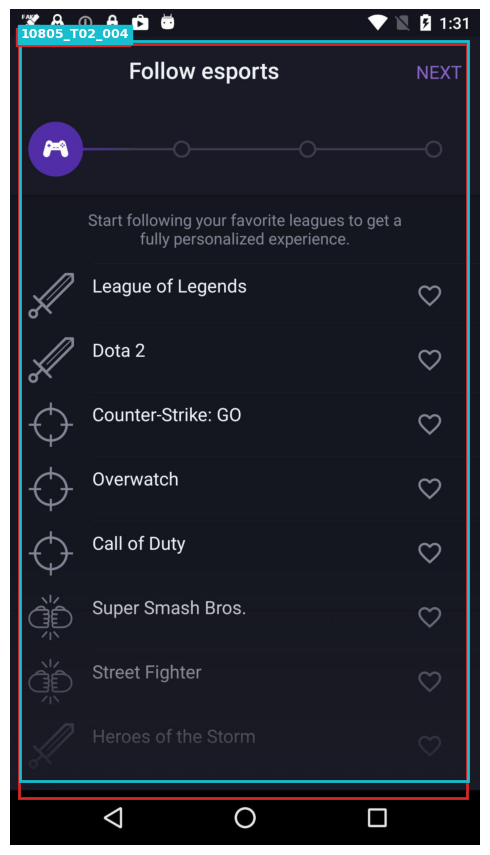

,comment_id,screen_id,screen_task_id,comment_source,expected_standard,observed_issue,suggested_fix,missing_parts,bounding_box
0,10805_T02_001,10805,10805_T02,LLM,the design should be visually appealing and use a consistent color scheme.,the colors used are too dark and the overall design is not visually appealing. The lack of contrast between the text and the background makes it difficult t...,the colors could be changed to something lighter and more contrasting.,[],"{'x_max': 0.97135962, 'x_min': 0.01832761, 'y_max': 0.94315431, 'y_min': 0.04123711}"
1,10805_T02_004,10805,10805_T02,LLM,the design should be visually appealing and use a consistent color scheme.,the colors used are too dark and the overall design is not visually appealing. The lack of contrast between the text and the background makes it difficult t...,the colors could be changed to something lighter and more contrasting. The overall design could also be improved by using more white space and simplifying t...,[],"{'x_max': 0.97441772, 'x_min': 0.02138221, 'y_max': 0.92268041, 'y_min': 0.03780069}"


In [8]:
SCREEN_IMAGE_DIR = SCREENS_DIR

def show_task_duplicate_group(group_idx):
    if group_idx < 0 or group_idx >= len(task_duplicate_groups):
        raise IndexError(f"group_idx must be between 0 and {len(task_duplicate_groups) - 1}")

    group_df = task_duplicate_groups[group_idx]
    group_comment_ids = set(group_df["comment_id"])
    pair_df = task_duplicate_review_pairs_df[
        task_duplicate_review_pairs_df["left_comment_id"].isin(group_comment_ids)
        & task_duplicate_review_pairs_df["right_comment_id"].isin(group_comment_ids)
    ]

    print(f"Task duplicate group {group_idx + 1}/{len(task_duplicate_groups)}")
    print("screen_task_id:", group_df["screen_task_id"].iloc[0])
    if len(pair_df):
        print("bbox IoU range:", round(pair_df["bbox_iou"].min(), 2), "to", round(pair_df["bbox_iou"].max(), 2))

    rows_with_bbox = group_df[group_df["bounding_box"].apply(lambda box: bbox_to_tuple(box) is not None)]
    if len(rows_with_bbox):
        show_screen(
            screen_id=group_df["screen_id"].iloc[0],
            bboxes=rows_with_bbox["bounding_box"].tolist(),
            image_dir=SCREEN_IMAGE_DIR,
            labels=rows_with_bbox["comment_id"].tolist(),
            width=500,
        )
    else:
        print("No valid bounding boxes to display for this group.")

    return group_df[[
        "comment_id",
        "screen_id",
        "screen_task_id",
        "comment_source",
        "expected_standard",
        "observed_issue",
        "suggested_fix",
        "missing_parts",
        "bounding_box",
    ]]

show_task_duplicate_group(0) if task_duplicate_groups else print("No bbox-aware observed-issue duplicate groups to review.")


In [9]:
# Fixed survivor choices from the completed manual review of every task duplicate group.
TASK_MANUAL_KEEP_COMMENT_IDS = [
    "10805_T02_004",
    "2120_T02_002",
    "22172_T01_004",
    "3297_T03_004",
    "34639_T03_005",
    "42468_T02_005",
    "45775_T02_003",
    "49571_T02_001",
    "58314_T03_002",
    "60844_T02_003",
    "62580_T03_001",
    "63515_T03_005",
    "66205_T02_001",
    "71337_T02_002",
    "9520_T01_004",
]


In [10]:
def apply_task_manual_choices(keep_comment_ids):
    if len(task_duplicate_groups) == 0:
        return task_dedup_comments_df

    if len(keep_comment_ids) != len(task_duplicate_groups):
        raise ValueError(f"Provide exactly one comment_id per bbox-aware task duplicate group ({len(task_duplicate_groups)} total).")

    chosen = set(keep_comment_ids)
    review_comment_ids = set(task_duplicate_review_df["comment_id"])
    if not chosen.issubset(review_comment_ids):
        raise ValueError("All chosen comment_id values must come from bbox-aware task duplicate groups.")

    chosen_group_count = sum(
        bool(set(group_df["comment_id"]) & chosen)
        for group_df in task_duplicate_groups
    )
    if chosen_group_count != len(task_duplicate_groups):
        raise ValueError("Choose exactly one survivor from each bbox-aware duplicate group.")

    return pd.concat([
        task_dedup_comments_df[~task_dedup_comments_df["comment_id"].isin(review_comment_ids)],
        task_dedup_comments_df[task_dedup_comments_df["comment_id"].isin(chosen)],
    ], ignore_index=True).sort_values(
        ["screen_task_id", "comment_label", "comment_id"],
        kind="stable",
    ).reset_index(drop=True)
task_reference_comments_df = apply_task_manual_choices(TASK_MANUAL_KEEP_COMMENT_IDS)


## 1.6 Build Final Task-Shaped Output

Reshape back to one row per task with a `comments` list of dictionaries; tasks left without comments are dropped.

In [11]:
final_human_reference_df = nest_comments(task_reference_comments_df)

print("Screen tasks without remaining comments (dropped):", uicrit_df["screen_task_id"].nunique() - len(final_human_reference_df))
print("Final screen_task rows:", len(final_human_reference_df))
display(final_human_reference_df.assign(num_comments=final_human_reference_df["comments"].map(len)).drop(columns="comments").head(3))

Screen tasks without remaining comments (dropped): 3
Final screen_task rows: 2952


,screen_id,app,app_category,screen_task_id,task,num_comments
0,15,Seven - 7 Minute Workout,Health & Fitness,15_T01,Plan and Start Full Body Workouts,9
1,15,Seven - 7 Minute Workout,Health & Fitness,15_T02,Tap on the Plus icon or explore the Workout Plans.,6
2,15,Seven - 7 Minute Workout,Health & Fitness,15_T03,select and get started with Full body workouts,4


## 1.7 Validation Check

No same-issue duplicates with overlapping, ambiguous or missing boxes may remain.

In [12]:
unresolved_task_duplicate_review_df, _ = find_bbox_duplicate_components(
    task_reference_comments_df,
    TASK_TEXT_DEDUP_KEY,
    REVIEW_EDGE_STATUSES,
)
assert unresolved_task_duplicate_review_df.empty, "Same-issue duplicates remain; resolve them manually first."
print("Validation passed.")

Validation passed.


## 1.8 Save Exact-Dedup Output

In [ ]:
final_human_reference_df.to_parquet(EXACT_DEDUP_PATH, index=False)
print("Saved:", EXACT_DEDUP_PATH)

# 2. Semantic Duplicates Within The Same Task

Workflow:
- pair every two comments of the same task and score each pair by embedding cosine similarity
- send pairs with cosine similarity of at least 0.40 to two LLM judges (OpenAI and Gemini batch APIs)
- combine both judges into a conservative consensus; survivor-direction conflicts get a manual decision
- resolve the keep_A / keep_B decisions into merge components, drop the non-survivors and save

## 2.0 Imports

In [13]:
from utils.batch_manager import BatchConfig, BatchManager, build_batch_adapter
from utils.comments.dedup import cosine_similarity, load_decisions, merge_components, review_pairs
from utils.comments.judge import DUPLICATE_REVIEW, compare_judges, failed_ids, iter_requests, read_results
from utils.models_setup import resolve_model_config, setup_client

SEMANTIC_SCORED_PAIRS_PATH = OUTPUT_DIR / "semantic_scored_pairs.parquet"

## 2.1 Build Comment-Level Input

One row per comment of the exact-dedup reference.

In [14]:
semantic_comments_df = explode_comments(pd.read_parquet(EXACT_DEDUP_PATH), "comments")

print("Comment-level rows for semantic dedup:", len(semantic_comments_df))
print("Tasks represented:", semantic_comments_df["screen_task_id"].nunique())

Comment-level rows for semantic dedup: 11330
Tasks represented: 2952


## 2.2 Generate Within-Task Candidate Pairs

Every unordered pair of comments within the same `screen_task_id`, with `left_`/`right_` comment columns.

In [15]:
comment_cols = [col for col in semantic_comments_df.columns if col not in TASK_METADATA_COLS]
semantic_comment_pairs_df = (
    semantic_comments_df.rename(columns={col: f"left_{col}" for col in comment_cols})
    .merge(
        semantic_comments_df[["screen_task_id", *comment_cols]].rename(columns={col: f"right_{col}" for col in comment_cols}),
        on="screen_task_id",
    )
    .query("left_comment_id < right_comment_id")
    .reset_index(drop=True)
)
semantic_comment_pairs_df["bbox_iou"] = [
    bbox_iou(left, right)
    for left, right in zip(semantic_comment_pairs_df["left_bounding_box"], semantic_comment_pairs_df["right_bounding_box"])
]

print("Within-task candidate pairs:", len(semantic_comment_pairs_df))
print("Candidate pairs per task:")
print(semantic_comment_pairs_df.groupby("screen_task_id").size().describe().round(2))

Within-task candidate pairs: 21529
Candidate pairs per task:
count    2730.00
mean        7.89
std         8.34
min         1.00
25%         3.00
50%         6.00
75%        10.00
max        78.00
dtype: float64


## 2.3 Cosine Similarity And Checkpoint

Cosine similarity of the comments' embeddings only selects and orders pairs for LLM-as-judge review; no comment is
dropped on cosine similarity alone. The scored pairs are saved so Section 2.4 can resume without recomputing embeddings.

In [16]:
if SEMANTIC_SCORED_PAIRS_PATH.exists():
    print("Loaded scored pairs (delete the file to recompute):", SEMANTIC_SCORED_PAIRS_PATH)
else:
    semantic_comment_pairs_df["cosine_similarity"] = cosine_similarity(semantic_comment_pairs_df, semantic_comments_df)
    semantic_comment_pairs_df.to_parquet(SEMANTIC_SCORED_PAIRS_PATH, index=False)
    print("Saved scored pairs:", SEMANTIC_SCORED_PAIRS_PATH)

Loaded scored pairs (delete the file to recompute): cleaned_dataset/deduplicating_semantic_human_critiques/semantic_scored_pairs.parquet


## 2.4 LLM-as-Judge Flow

Configure the judge, build candidate pairs, write request JSONL, submit, retrieve, then parse the returned decisions.

### 2.4.0 Configure Judge Run

`BATCH_JUDGE` is the judge whose batches the next cells write, submit and retry; both judges are compared in 2.4.7.

In [ ]:
SEMANTIC_REVIEW_DIR = OUTPUT_DIR / "llmjudge_semantic_review"
SEMANTIC_REVIEW_TASK = "semantic_duplicate"
SEMANTIC_MANUAL_DECISIONS_PATH  = OUTPUT_DIR / "semantic_manual_decisions.csv"

REVIEW_LOWER_BOUND = 0.40
IMAGE_FORMAT = "jpeg"
REVIEW_MAX_TOKENS = 2048
REVIEW_TEMPERATURE = 0.0

BATCH_JUDGE = "gemini"  # "openai" | "gemini"
JUDGE_CONFIGS = {provider: resolve_model_config(provider) for provider in ("openai", "gemini")}
REVIEW_MODEL = JUDGE_CONFIGS[BATCH_JUDGE]["model_version"]
REVIEW_MODEL_SHORT = JUDGE_CONFIGS[BATCH_JUDGE]["model_short"]

semantic_client, _ = setup_client(
    BATCH_JUDGE,
    system_message=DUPLICATE_REVIEW.system_prompt,
    temperature=REVIEW_TEMPERATURE,
    max_tokens=REVIEW_MAX_TOKENS,
)
semantic_batch = BatchManager(build_batch_adapter(semantic_client, BatchConfig(
    provider=BATCH_JUDGE,
    model=REVIEW_MODEL,
    batch_main_dir=SEMANTIC_REVIEW_DIR / REVIEW_MODEL_SHORT,
    selected_tasks=SEMANTIC_REVIEW_TASK,
    temperature=REVIEW_TEMPERATURE,
    max_tokens=REVIEW_MAX_TOKENS,
    system_message=DUPLICATE_REVIEW.system_prompt,
    image_format=IMAGE_FORMAT,
)))


def semantic_review_response_paths(model_short):
    """Batch response files, then retry response files in run order; later records replace earlier ones."""
    responses_dir = SEMANTIC_REVIEW_DIR / model_short / "Batch_Responses"

    def numbered(kind):
        paths = responses_dir.glob(f"responses-{SEMANTIC_REVIEW_TASK}-{kind}_*.jsonl")
        return sorted(paths, key=lambda path: int(path.stem.rsplit("_", 1)[1]))

    return numbered("batch") + numbered("retry")


print("Batch judge:", REVIEW_MODEL_SHORT, "->", semantic_batch.root)

### 2.4.1 Build Review Candidates

Keep pairs at or above the cosine lower bound; `custom_id` identifies each pair in batch requests and responses.

In [19]:
scored_semantic_pairs_df = pd.read_parquet(SEMANTIC_SCORED_PAIRS_PATH)
screenshots_df = pd.read_parquet(PREPROCESSED_DIR / "screenshots.parquet")
semantic_review_base64_screen_lookup = dict(zip(screenshots_df["screen_id"], screenshots_df["base64_screen"]))

semantic_review_candidate_pairs_df = scored_semantic_pairs_df[
    scored_semantic_pairs_df["cosine_similarity"] >= REVIEW_LOWER_BOUND
].sort_values(
    ["screen_task_id", "cosine_similarity", "bbox_iou"],
    ascending=[True, False, False],
    kind="stable",
).reset_index(drop=True)
semantic_review_candidate_pairs_df["custom_id"] = (
    "semantic_pair::" + semantic_review_candidate_pairs_df["left_comment_id"]
    + "::" + semantic_review_candidate_pairs_df["right_comment_id"]
)

print("Review candidate pairs:", len(semantic_review_candidate_pairs_df))

Review candidate pairs: 8867


### 2.4.2 Write Batch Requests

In [ ]:
if any(semantic_batch.requests_dir.glob(f"requests-{SEMANTIC_REVIEW_TASK}-batch_*.jsonl")):
    print("Request files already exist (delete them to rebuild):", semantic_batch.requests_dir)
else:
    semantic_batch.write_request_batches_jsonl(
        iter_requests(
            semantic_review_candidate_pairs_df,
            DUPLICATE_REVIEW,
            screens=semantic_review_base64_screen_lookup,
            provider=BATCH_JUDGE,
            model=REVIEW_MODEL,
            image_format=IMAGE_FORMAT,
            temperature=REVIEW_TEMPERATURE,
            max_tokens=REVIEW_MAX_TOKENS,
        ),
        max_mb_per_file=180,
    )

### 2.4.3 Preview One Request

In [ ]:
semantic_batch.preview_request(index=0, display=True)

### 2.4.4 Run Batch Workflow

Upload each request batch file and run its provider batch job. Reruns skip batch files whose responses are already downloaded.

In [ ]:
START_FROM_BATCH = 1
RESUME_BATCH_ID = None  # paste an active batch id here after restart, otherwise None

semantic_batch.process_batches_sequentially(
    start_from_batch=START_FROM_BATCH,
    sleep_minutes=5,
    resume_batch_id=RESUME_BATCH_ID,
)


Processing batch file: requests-semantic_duplicate-batch_1.jsonl
Uploaded: requests-semantic_duplicate-batch_1.jsonl -> ID: files/ukf594jmbdgt
Batch created | ID: batches/sf3ldx6dpl2gkflaatlvhwnmplgfo8mhsg8p | Status: JOB_STATE_PENDING
Saved batch output to responses-semantic_duplicate-batch_1.jsonl

Processing batch file: requests-semantic_duplicate-batch_2.jsonl
Uploaded: requests-semantic_duplicate-batch_2.jsonl -> ID: files/jpcusugmxr7k
Batch created | ID: batches/l09djw06sjtlji3s240unttjaslk5wx644ju | Status: JOB_STATE_PENDING
Saved batch output to responses-semantic_duplicate-batch_2.jsonl

Processing batch file: requests-semantic_duplicate-batch_3.jsonl
Uploaded: requests-semantic_duplicate-batch_3.jsonl -> ID: files/mxkibbo2p59z
Batch created | ID: batches/svo6vjx6uybh6vyru7wzqy6mk6i7q09e9bnr | Status: JOB_STATE_PENDING
Saved batch output to responses-semantic_duplicate-batch_3.jsonl

Processing batch file: requests-semantic_duplicate-batch_4.jsonl
Uploaded: requests-semantic_

### 2.4.5 Parse Judge Responses

In [20]:
semantic_review_results_df = read_results(semantic_review_response_paths(REVIEW_MODEL_SHORT), DUPLICATE_REVIEW).merge(
    semantic_review_candidate_pairs_df, on="custom_id", how="left", validate="one_to_one"
)
retry_ids = failed_ids(semantic_review_results_df, semantic_review_candidate_pairs_df["custom_id"])

print("Responses:", len(semantic_review_results_df))
print("Expected pairs without a valid answer:", len(retry_ids))
if semantic_review_results_df["error"].notna().any():
    print(semantic_review_results_df["error"].value_counts().to_string())
print(semantic_review_results_df["recommended_action"].value_counts().sort_index().to_string())
display(semantic_review_results_df[[
    "custom_id",
    "relationship",
    "reasoning",
    "recommended_action",
    "confidence",
    "task",
    "left_observed_issue",
    "right_observed_issue",
    "cosine_similarity",
    "bbox_iou",
]].head(5))

Responses: 8867
Expected pairs without a valid answer: 0
recommended_action
keep_A        787
keep_B        346
keep_both    7734


,custom_id,relationship,reasoning,recommended_action,confidence,task,left_observed_issue,right_observed_issue,cosine_similarity,bbox_iou
0,semantic_pair::16562_T02_001::16562_T02_002,different,"Comment A addresses poor color contrast on the measurement unit labels on the right, while Comment B focuses on the small font size within the unit toggle b...",keep_both,0.95,Manage settings,"there is a lack of color contrast between the text and background, both of which are very similar shades of gray.","the text size appears to be too small, which can make it difficult to read comfortably.",0.523846,0.00000
1,semantic_pair::16595_T01_001::16595_T01_002,different,"Comment A targets the hamburger menu icon in the top bar, whereas Comment B targets the horizontal navigation tab bar below it.",keep_both,0.78,Review bookmarked auctions or explore other available auction options.,the Menu button is not visually prominent.,the Navigation bar is not visually prominent.,0.755624,0.00000
2,semantic_pair::16595_T01_005::16595_T01_006,different,"Comment A targets page clutter in the main content area, while Comment B focuses on tab text legibility and contrast.",keep_both,0.78,Review bookmarked auctions or explore other available auction options.,"there are too many elements on the page, which makes it look cluttered and difficult to understand.",the text is difficult to read because it is too small and there is not enough contrast between the text and the background.,0.568964,0.00000
3,semantic_pair::16595_T01_004::16595_T01_005,different,"Comment A critiques the design for being too basic, while Comment B complains about clutter and too many elements. These are distinct criticisms.",keep_both,0.72,Review bookmarked auctions or explore other available auction options.,the app's design appears to be rather basic and lacks visual appeal.,"there are too many elements on the page, which makes it look cluttered and difficult to understand.",0.478412,0.14272
4,semantic_pair::16595_T01_001::16595_T01_006,different,"Comment A targets the menu button icon visibility, whereas Comment B addresses readability and contrast of the tab bar text labels.",keep_both,0.70,Review bookmarked auctions or explore other available auction options.,the Menu button is not visually prominent.,the text is difficult to read because it is too small and there is not enough contrast between the text and the background.,0.422137,0.00000


### 2.4.6 Retry Failed Judge Responses

In [ ]:
print("Failed semantic review ids:", len(retry_ids))
if retry_ids:
    print("Examples:", sorted(retry_ids)[:10])

retry_number = len(list(semantic_batch.responses_dir.glob(f"responses-{SEMANTIC_REVIEW_TASK}-retry_*.jsonl"))) + 1
retry_requests_path = semantic_batch.requests_dir / f"requests-{SEMANTIC_REVIEW_TASK}-retry_{retry_number}.jsonl"
retry_responses_base_name = f"responses-{SEMANTIC_REVIEW_TASK}-retry_{retry_number}"

1. Build a retry request file from the batch request files.

In [ ]:
if not retry_ids:
    print("Skipping retry request build.")
else:
    retry_summary = semantic_batch.build_retry_requests_from_failed_requests(
        retry_ids,
        source_requests_file=semantic_batch.requests_dir,
        output_file=retry_requests_path,
    )

    if retry_summary["written"] != len(retry_ids):
        raise ValueError(f"Expected {len(retry_ids)} retry request(s), wrote {retry_summary['written']}.")

2. Upload, run, poll and retrieve the retry batch.

In [ ]:
if not retry_ids:
    print("Skipping retry batch run.")
else:
    file_id = semantic_batch.upload_file(retry_requests_path)
    semantic_batch.create_batch(input_file_id=file_id)
    print("Retry batch id:", semantic_batch.batch_id)

    retry_responses_path = semantic_batch._poll_then_retrieve(base_name=retry_responses_base_name)
    if retry_responses_path is None:
        raise RuntimeError(f"Retry batch did not complete successfully: {semantic_batch.batch_id}")

    print("Retry response path:", retry_responses_path)

3. Check again; retry records replace the failed ones.

In [ ]:
retry_ids = failed_ids(
    read_results(semantic_review_response_paths(REVIEW_MODEL_SHORT), DUPLICATE_REVIEW),
    semantic_review_candidate_pairs_df["custom_id"],
)
print("Expected pairs without a valid answer after retry:", len(retry_ids))

### 2.4.7 Compare The Two Judges

In [21]:
semantic_review_judge_results = {
    config["model_short"]: read_results(semantic_review_response_paths(config["model_short"]), DUPLICATE_REVIEW)
    for config in JUDGE_CONFIGS.values()
}
left_judge, right_judge = semantic_review_judge_results
left_action_col, right_action_col = f"recommended_action__{left_judge}", f"recommended_action__{right_judge}"
left_relationship_col, right_relationship_col = f"relationship__{left_judge}", f"relationship__{right_judge}"

semantic_review_judge_comparison_df = compare_judges(
    semantic_review_judge_results,
    ["relationship", "recommended_action", "confidence", "reasoning"],
).merge(semantic_review_candidate_pairs_df, on="custom_id", validate="one_to_one")
same_action = semantic_review_judge_comparison_df[left_action_col].eq(semantic_review_judge_comparison_df[right_action_col])

print("Compared judges:", left_judge, "vs", right_judge)
print(
    "Same relationship rate:",
    semantic_review_judge_comparison_df[left_relationship_col].eq(semantic_review_judge_comparison_df[right_relationship_col]).mean(),
)
print("Same recommended action rate:", same_action.mean())
display(pd.crosstab(
    semantic_review_judge_comparison_df[left_action_col],
    semantic_review_judge_comparison_df[right_action_col],
    dropna=False,
))
display(semantic_review_judge_comparison_df.loc[~same_action, [
    "custom_id",
    left_relationship_col,
    right_relationship_col,
    left_action_col,
    right_action_col,
    "left_observed_issue",
    "right_observed_issue",
]].head(5))

Compared judges: gpt5_2 vs gemini_3_7_flash
Same relationship rate: 0.7465884741175144
Same recommended action rate: 0.8970339460922522


recommended_action__gemini_3_7_flash,keep_A,keep_B,keep_both
recommended_action__gpt5_2,,,
keep_A,502,22,271
keep_B,136,278,289
keep_both,149,46,7174


,custom_id,relationship__gpt5_2,relationship__gemini_3_7_flash,recommended_action__gpt5_2,recommended_action__gemini_3_7_flash,left_observed_issue,right_observed_issue
1,semantic_pair::10089_T02_005::10089_T02_006,a_contains_b,different,keep_A,keep_both,the text font size is small and a little difficult to read.,the text font size is small.
4,semantic_pair::10089_T02_006::10089_T02_007,b_contains_a,partial_overlap,keep_B,keep_both,the text font size is small.,the text is difficult to read because it is too small and there is not enough contrast between the text and the background.
29,semantic_pair::10122_T01_003::10122_T01_008,b_contains_a,different,keep_B,keep_both,the text (Lock) is not visually prominent.,the text is difficult to read because it is too small and there is not enough contrast between the text and the background.
53,semantic_pair::10126_T03_001::10126_T03_002,duplicate,different,keep_A,keep_both,the label is not fully readable.,the label is not fully readable.
54,semantic_pair::10126_T03_005::10126_T03_006,duplicate,different,keep_A,keep_both,the image is not clearly visible.,the image is not clearly visible.


### 2.4.8 Build Consensus Decisions

Decision policy:

- If both judges recommend the same action, accept that action.
- If both judges call the pair a `duplicate` but disagree on the survivor (`keep_A` vs `keep_B`), decide manually (2.4.9).
- For all other disagreements, keep both comments.

Manual decisions are saved to `semantic_manual_decisions.csv` and override the consensus wherever they exist.

In [22]:
if semantic_review_judge_comparison_df[[left_action_col, right_action_col]].isna().any(axis=None):
    raise ValueError("The two judges' results do not cover the same candidate pairs.")


def consensus_review_decision(row):
    left_action, right_action = row[left_action_col], row[right_action_col]
    if left_action == right_action:
        return left_action, "judge_agreement"
    if {left_action, right_action} == {"keep_A", "keep_B"} and row[left_relationship_col] == row[right_relationship_col] == "duplicate":
        return "manual_review", "survivor_direction_conflict"
    return "keep_both", "conservative_disagreement_keep_both"


def apply_manual_decisions(decisions_df):
    decisions_df["final_decision"] = (
        decisions_df["custom_id"].map(load_decisions(SEMANTIC_MANUAL_DECISIONS_PATH)).fillna(decisions_df["consensus_decision"])
    )


accepted_review_decisions_df = semantic_review_judge_comparison_df.copy()
accepted_review_decisions_df[["consensus_decision", "decision_source"]] = accepted_review_decisions_df.apply(
    consensus_review_decision, axis=1, result_type="expand"
)
apply_manual_decisions(accepted_review_decisions_df)

print(accepted_review_decisions_df["decision_source"].value_counts().sort_index().to_string())
print("Saved manual decisions:", len(load_decisions(SEMANTIC_MANUAL_DECISIONS_PATH)))
print("Rows still needing manual review:", accepted_review_decisions_df["final_decision"].eq("manual_review").sum())

decision_source
conservative_disagreement_keep_both     830
judge_agreement                        7954
survivor_direction_conflict              83
Saved manual decisions: 83
Rows still needing manual review: 0


### 2.4.9 Review Survivor-Direction Conflicts

Pairs where both judges collapse the duplicate but disagree about which comment survives. Only pairs without a saved
decision are shown, and each decision is saved immediately, so this cell can be stopped and rerun at any time.

In [23]:
review_pairs(
    accepted_review_decisions_df[accepted_review_decisions_df["consensus_decision"].eq("manual_review")],
    SEMANTIC_MANUAL_DECISIONS_PATH,
)
apply_manual_decisions(accepted_review_decisions_df)

print("Unresolved manual-review rows:", accepted_review_decisions_df["final_decision"].eq("manual_review").sum())
print(accepted_review_decisions_df["final_decision"].value_counts().sort_index().to_string())

Unresolved manual-review rows: 0
final_decision
keep_A        542
keep_B        316
keep_both    8009


### 2.4.10 Audit Low-IoU Agreed Drops

In [24]:
LOW_IOU_DROP_AUDIT_THRESHOLD = 0.20

agreed_drops_df = accepted_review_decisions_df[
    accepted_review_decisions_df["final_decision"].isin(["keep_A", "keep_B"])
    & accepted_review_decisions_df["decision_source"].eq("judge_agreement")
]
low_iou_agreed_drops_df = agreed_drops_df[agreed_drops_df["bbox_iou"].fillna(0).lt(LOW_IOU_DROP_AUDIT_THRESHOLD)]

print(f"Low-IoU agreed drops: {len(low_iou_agreed_drops_df)} of {len(agreed_drops_df)}")
display(low_iou_agreed_drops_df[[
    "custom_id",
    "final_decision",
    "bbox_iou",
    "cosine_similarity",
    "left_observed_issue",
    "right_observed_issue",
]].sort_values("bbox_iou").head(5))

Low-IoU agreed drops: 63 of 780


,custom_id,final_decision,bbox_iou,cosine_similarity,left_observed_issue,right_observed_issue
0,semantic_pair::10089_T01_001::10089_T01_002,keep_B,0.0,1.000000,"the menu icon is extending beyond the screen edges, causing it to be partially or completely cut off from view.","the menu icon is extending beyond the screen edges, causing it to be partially or completely cut off from view."
1009,semantic_pair::16595_T03_001::16595_T03_003,keep_B,0.0,0.853979,the text is too small and difficult to read.,the text is difficult to read because it is too small and there is not enough contrast between the text and the background.
1321,semantic_pair::19298_T03_002::19298_T03_003,keep_A,0.0,0.904442,the form fields lack clarity and fail to clearly indicate the required information.,the form fields are not clear and it is not obvious what information is required.
1704,semantic_pair::23441_T01_001::23441_T01_003,keep_A,0.0,1.000000,text is not visible due to poor color contrast and the top paragraph is less visible than the bottom paragraph,text is not visible due to poor color contrast and the top paragraph is less visible than the bottom paragraph
2010,semantic_pair::25713_T03_003::25713_T03_004,keep_A,0.0,0.652338,"there are too many elements on the screen, which makes it difficult to focus on the important information.","there are too many elements on the page, which makes the design look cluttered."


### 2.4.11 Resolve Merge Components And Rebuild Dataset

Comments linked by keep_A / keep_B decisions form components. A component may keep several comments (its survivors
were judged different issues), but if every comment in it would be dropped the decisions contradict each other
(e.g. A drops B and B drops A); such components are reviewed again before comments are dropped.

#### Audit Merge Components

In [25]:
if accepted_review_decisions_df["final_decision"].eq("manual_review").any():
    raise ValueError("Resolve final_decision='manual_review' rows (2.4.9) before rebuilding the semantic-dedup dataset.")

final_semantic_drop_ids, problem_merge_review_rows_df = merge_components(accepted_review_decisions_df)

print("Pairwise merge decisions:", accepted_review_decisions_df["final_decision"].isin(["keep_A", "keep_B"]).sum())
print("Comments marked to drop:", len(final_semantic_drop_ids))
print("Contradicting components:", problem_merge_review_rows_df["component_id"].nunique())
display(problem_merge_review_rows_df[[
    "component_id",
    "custom_id",
    "final_decision",
    "bbox_iou",
    "left_observed_issue",
    "right_observed_issue",
]])

Pairwise merge decisions: 858
Comments marked to drop: 837
Contradicting components: 0


,component_id,custom_id,final_decision,bbox_iou,left_observed_issue,right_observed_issue


#### Resolve Problem Components

In [26]:
review_pairs(problem_merge_review_rows_df, SEMANTIC_MANUAL_DECISIONS_PATH)
apply_manual_decisions(accepted_review_decisions_df)
final_semantic_drop_ids, problem_merge_review_rows_df = merge_components(accepted_review_decisions_df)

print("Remaining contradicting components:", problem_merge_review_rows_df["component_id"].nunique())
if len(problem_merge_review_rows_df):
    display(problem_merge_review_rows_df)
    raise ValueError("Resolve the remaining contradicting components before applying drops.")

Remaining contradicting components: 0


#### Rebuild Semantic-Dedup Table

In [27]:
semantic_dedup_comments_df = nest_comments(
    semantic_comments_df[~semantic_comments_df["comment_id"].isin(final_semantic_drop_ids)]
)

print("Comments before semantic dedup:", len(semantic_comments_df))
print("Comments dropped:", len(final_semantic_drop_ids))
print("Task rows after semantic dedup:", len(semantic_dedup_comments_df))
display(semantic_dedup_comments_df.head(3))

Comments before semantic dedup: 11330
Comments dropped: 837
Task rows after semantic dedup: 2952


,screen_id,app,app_category,screen_task_id,task,comments
0,15,Seven - 7 Minute Workout,Health & Fitness,15_T01,Plan and Start Full Body Workouts,"[{'comment_id': '15_T01_001', 'comment_label': 'Comment 1', 'comment_source': 'Human', 'expected_standard': 'the text’s visual treatment and formatting shou..."
1,15,Seven - 7 Minute Workout,Health & Fitness,15_T02,Tap on the Plus icon or explore the Workout Plans.,"[{'comment_id': '15_T02_001', 'comment_label': 'Comment 1', 'comment_source': 'Human', 'expected_standard': 'make the most important information visually do..."
2,15,Seven - 7 Minute Workout,Health & Fitness,15_T03,select and get started with Full body workouts,"[{'comment_id': '15_T03_001', 'comment_label': 'Comment 1', 'comment_source': 'LLM', 'expected_standard': 'The text’s visual treatment and formatting should..."


## 2.5 Save Semantic-Dedup Output

In [ ]:
semantic_dedup_comments_df.to_parquet(SEMANTIC_DEDUP_PATH, index=False)
print("Saved:", SEMANTIC_DEDUP_PATH)

## 2.6 Most Frequent Expert Comments After Normalization

Repeated expert critique text in the saved semantic-dedup reference (UICrit's LLM-written comments excluded).

In [ ]:
expert_comment_rows_df = explode_comments(pd.read_parquet(SEMANTIC_DEDUP_PATH), "comments")
expert_comment_rows_df = expert_comment_rows_df[expert_comment_rows_df["comment_source"].ne("LLM")]
expert_comment_rows_df["observed_issue_norm"] = expert_comment_rows_df["observed_issue"].map(normalize_text)

most_frequent_expert_comments_df = (
    expert_comment_rows_df
    .groupby("observed_issue_norm")
    .agg(
        frequency=("observed_issue_norm", "size"),
        example_observed_issue=("observed_issue", "first"),
        example_expected_standard=("expected_standard", "first"),
        example_suggested_fix=("suggested_fix", "first"),
        tasks=("screen_task_id", "nunique"),
        screens=("screen_id", "nunique"),
        apps=("app", lambda values: ", ".join(sorted(values.dropna().astype(str).unique())[:5])),
    )
    .reset_index()
    .sort_values(["frequency", "tasks", "screens", "observed_issue_norm"], ascending=[False, False, False, True])
    .reset_index(drop=True)
)

print("Expert comments counted:", len(expert_comment_rows_df))
print("Unique normalized observed issues:", len(most_frequent_expert_comments_df))
display(most_frequent_expert_comments_df.head(25))